### Biofisiología Vegetal - Rendimiento de Cultivos (PlantGrowth)

Este dataset clásico, ampliamente citado en literatura biométrica, registra el peso seco de plantas bajo un grupo control y dos condiciones de tratamiento.

### Análisis Exploratorio de Datos (EDA)

Es fundamental visualizar la dispersión y los estadísticos descriptivos antes de aplicar el test.


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



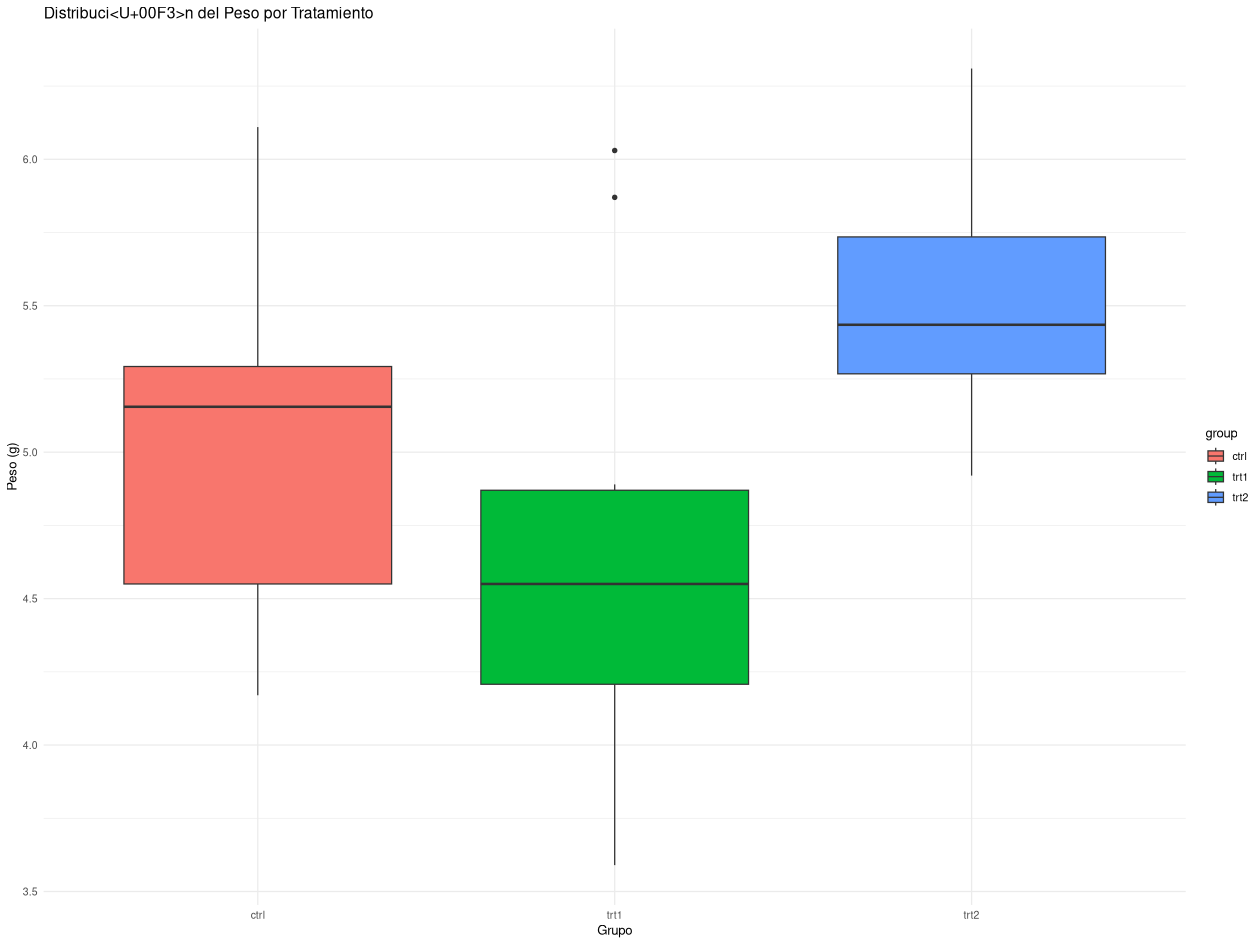

In [1]:
data("PlantGrowth")
library(ggplot2)
library(dplyr)

# Resumen descriptivo por grupo
PlantGrowth %>%
  group_by(group) %>%
  summarise(n = n(), media = mean(weight), sd = sd(weight))

# Visualización (Boxplot)
ggplot(PlantGrowth, aes(x = group, y = weight, fill = group)) +
  geom_boxplot() +
  labs(title = "Distribución del Peso por Tratamiento", x = "Grupo", y = "Peso (g)") +
  theme_minimal()

In [ ]:
# Anova una via
anova_result <- aov(weight ~ group, data = PlantGrowth)
summary(anova_result)

            Df Sum Sq Mean Sq F value Pr(>F)  
group        2  3.766  1.8832   4.846 0.0159 *
Residuals   27 10.492  0.3886                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [3]:
# Post-hoc pairwise comparisons using Tukey HSD
TukeyHSD(anova_result)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = weight ~ group, data = PlantGrowth)

$group
            diff        lwr       upr     p adj
trt1-ctrl -0.371 -1.0622161 0.3202161 0.3908711
trt2-ctrl  0.494 -0.1972161 1.1852161 0.1979960
trt2-trt1  0.865  0.1737839 1.5562161 0.0120064


**Interpretación**: Si el valor p es menor que el nivel de significancia $\alpha = 0.05$, rechazamos $H_0$, concluyendo que al menos un tratamiento difiere significativamente en su efecto sobre el peso.